# Brownlow 2022 Prediction
- Created by Jay Stein
- 3/9/22
- Purpose of this notebook is to make some awesome predictions for the upcoming Brownlow Medal

# Imports

## Standard Imports

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.mode.chained_assignment = None

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

## Imports for XGBoost

In [4]:
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


# Read in data
- Got this using that super R library `fitzRoy`

In [180]:
#data from afl table
afltable = pd.read_csv(r"C:\Users\User\Documents\R\test_proj\afl_table_stats_2022.csv", index_col=0)

C:\Users\User\AppData\Roaming\Python\Python39\site-packages\IPython\core\interactiveshell.py:3437: DtypeWarning: Columns (2,30,58) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [181]:
#get all footy tips
tips = pd.read_csv(r"C:/Users/User/Documents/R/test_proj/tips_combo_2017_to_2022.csv", index_col=0)

## Data Munging for Tips

In [182]:
tips_clean = tips[['round','year','hteam','hmargin']].dropna()

In [183]:
#we are taking the mean of the tips from range of sources
tips_summary = tips.groupby(['round','year','hteam'])['hmargin'].mean().reset_index()
tips_summary = tips_summary.sort_values(by=['year','round'])

## Data Munging

In [184]:
#replace dots with underscore
afltable.columns = afltable.columns.str.replace('.','_', regex=False)

In [185]:
afltable['Full_Name'] = afltable['First_name'] + ' ' + afltable['Surname']
afltable['Date'] = pd.to_datetime(afltable['Date']) #convert date to a date!
afltable['Round'] = afltable['Round'].astype('str')

In [186]:
#there are some finals in there... we can drop them
afltable_clean = afltable[~afltable["Round"].str.contains("F")]
afltable_clean["Round"] = afltable_clean["Round"].astype('int') #convert to int
afltable_clean = afltable_clean.reset_index(drop=True)

In [202]:
afltable_clean

,Season,Round,Date,Local_start_time,Venue,Attendance,Home_team,HQ1G,HQ1B,HQ2G,HQ2B,HQ3G,HQ3B,HQ4G,HQ4B,Home_score,Away_team,AQ1G,AQ1B,AQ2G,AQ2B,AQ3G,AQ3B,AQ4G,AQ4B,Away_score,First_name,Surname,ID,Jumper_No_,Playing_for,Kicks,Marks,Handballs,Goals,Behinds,Hit_Outs,Tackles,Rebounds,Inside_50s,Clearances,Clangers,Frees_For,Frees_Against,Brownlow_Votes,Contested_Possessions,Uncontested_Possessions,Contested_Marks,Marks_Inside_50,One_Percenters,Bounces,Goal_Assists,Time_on_Ground__,Substitute,Umpire_1,Umpire_2,Umpire_3,Umpire_4,group_id,Full_Name
0,2017,1,2017-03-23,1920,M.C.G.,73137,Carlton,4,3,7,4,12,4,14,5,89,Richmond,7,3,13,5,15,11,20,12,132,Dennis,Armfield,11673,27,Carlton,1,2,5,1,0,0,1,0,0,0,2,0,1,0,1,5,0,0,0,0,0,82,NaN,Sam Hay,Mathew Nicholls,Matt Stevic,NaN,NaN,Dennis Armfield
1,2017,1,2017-03-23,1920,M.C.G.,73137,Carlton,4,3,7,4,12,4,14,5,89,Richmond,7,3,13,5,15,11,20,12,132,Levi,Casboult,12114,41,Carlton,5,4,5,1,1,11,2,0,2,1,3,1,1,0,7,3,3,2,1,0,0,81,NaN,Sam Hay,Mathew Nicholls,Matt Stevic,NaN,NaN,Levi Casboult
2,2017,1,2017-03-23,1920,M.C.G.,73137,Carlton,4,3,7,4,12,4,14,5,89,Richmond,7,3,13,5,15,11,20,12,132,Patrick,Cripps,12261,9,Carlton,10,3,9,0,0,0,5,1,5,3,2,0,0,0,5,14,0,0,0,0,0,84,NaN,Sam Hay,Mathew Nicholls,Matt Stevic,NaN,NaN,Patrick Cripps
3,2017,1,2017-03-23,1920,M.C.G.,73137,Carlton,4,3,7,4,12,4,14,5,89,Richmond,7,3,13,5,15,11,20,12,132,Charlie,Curnow,12421,30,Carlton,7,4,1,0,0,0,5,0,4,0,3,0,1,0,2,6,0,0,1,0,0,76,NaN,Sam Hay,Mathew Nicholls,Matt Stevic,NaN,NaN,Charlie Curnow
4,2017,1,2017-03-23,1920,M.C.G.,73137,Carlton,4,3,7,4,12,4,14,5,89,Richmond,7,3,13,5,15,11,20,12,132,Ed,Curnow,11883,35,Carlton,13,5,6,0,0,0,4,0,3,5,4,1,2,0,5,11,0,0,0,2,0,86,NaN,Sam Hay,Mathew Nicholls,Matt Stevic,NaN,NaN,Ed Curnow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51079,2022,23,2022-08-21,1640,Docklands,23344,St Kilda,3,3,5,5,7,7,11,8,74,Sydney,4,2,9,3,11,6,13,10,88,Sam,Reid,11880,20,Sydney,6,4,6,0,2,4,5,0,0,2,5,0,4,0,10,2,3,0,2,0,0,79,NaN,Mathew Nicholls,Alex Whetton,Andrew Heffernan,NaN,NaN,Sam Reid
51080,2022,23,2022-08-21,1640,Docklands,23344,St Kilda,3,3,5,5,7,7,11,8,74,Sydney,4,2,9,3,11,6,13,10,88,James,Rowbottom,12714,8,Sydney,13,3,11,1,1,0,7,3,6,7,4,2,1,0,15,9,0,0,2,0,0,79,NaN,Mathew Nicholls,Alex Whetton,Andrew Heffernan,NaN,NaN,James Rowbottom
51081,2022,23,2022-08-21,1640,Docklands,23344,St Kilda,3,3,5,5,7,7,11,8,74,Sydney,4,2,9,3,11,6,13,10,88,Dylan,Stephens,12796,3,Sydney,14,5,3,0,0,0,1,1,3,1,2,1,2,0,6,14,0,0,0,0,1,77,NaN,Mathew Nicholls,Alex Whetton,Andrew Heffernan,NaN,NaN,Dylan Stephens
51082,2022,23,2022-08-21,1640,Docklands,23344,St Kilda,3,3,5,5,7,7,11,8,74,Sydney,4,2,9,3,11,6,13,10,88,Chad,Warner,12797,1,Sydney,10,0,10,1,1,0,5,1,4,2,5,1,0,0,11,8,0,0,1,1,0,89,NaN,Mathew Nicholls,Alex Whetton,Andrew Heffernan,NaN,NaN,Chad Warner


In [187]:
#check NaN
afltable_clean.isna().sum().sort_values(ascending=False)[:10]

group_id      51084
Substitute    51084
Umpire_4      47290
Umpire_3        664
Umpire_2        532
Season            0
Hit_Outs          0
Clearances        0
Inside_50s        0
Rebounds          0
dtype: int64

# Merge in Tipping Data

In [188]:
afltable_merged = afltable_clean.merge(tips_summary, how='left', 
                                      left_on=['Round','Season','Home_team'],
                                      right_on=['round','year','hteam'])
afltable_merged = afltable_merged.drop(columns=['round','year','hteam']) #we don't need these cols
afltable_merged.rename(columns={'hmargin':'Home_team_tipping'}, inplace=True)

## Minimal feature engineering

In [189]:
afltable_merged = (
    afltable_merged.
 assign(Player_at_home = (afltable_merged['Playing_for'] == afltable_merged['Home_team']).astype('int'),
        Player_team_score = np.where(afltable_merged['Playing_for'] == afltable_merged['Home_team'],
                             afltable_merged['Home_score'],
                             afltable_merged['Away_score']),
        Player_team_margin = np.where(afltable_merged['Playing_for'] == afltable_merged['Home_team'],
             afltable_merged['Home_score'] - afltable_merged['Away_score'],
             afltable_merged['Away_score'] - afltable_merged['Home_score']),
        Player_individual_score = afltable_merged['Goals']*6 + afltable_merged['Behinds']
       )
)

In [190]:
afltable_merged = afltable_merged.assign(
Player_prop_score = afltable_merged['Player_individual_score'] / afltable_merged['Player_team_score'],
Away_team_tipping = -1 * afltable_merged['Home_team_tipping'])

In [191]:
afltable_merged = afltable_merged.assign(
Player_team_tipping =  np.where(afltable_merged['Playing_for'] == afltable_merged['Home_team'],
                                afltable_merged['Home_team_tipping'],
                                afltable_merged['Away_team_tipping']))   

## Add in team proportions

In [192]:
proportion_features = ['Kicks', 'Marks', 'Handballs', 'Goals','Behinds', 'Hit_Outs', 'Tackles', 'Rebounds', 'Inside_50s', 'Clearances', 'Clangers', 
                'Frees_For', 'Frees_Against', 'Contested_Possessions', 'Uncontested_Possessions', 
                'Contested_Marks', 'Marks_Inside_50', 'One_Percenters', 'Bounces', 'Goal_Assists']

In [193]:
proportion_values = afltable_merged.groupby(['Season','Round','Venue','Playing_for'])[proportion_features].transform(lambda x: x/x.sum())
proportion_values = proportion_values.fillna(0) #fill in NaN

In [194]:
proportion_labels = [col + "_prop" for col in proportion_values.columns] #make some nice labels
proportion_values.columns = proportion_labels #assign new labels

In [195]:
afltable_merged = pd.concat([afltable_merged, proportion_values], axis=1)

In [196]:
afl_features = ['Season', 
                'Kicks', 'Marks', 'Handballs', 'Goals', 
                'Behinds', 'Hit_Outs', 'Tackles', 'Rebounds', 'Inside_50s', 'Clearances', 'Clangers', 
                'Frees_For', 'Frees_Against', 'Contested_Possessions', 'Uncontested_Possessions', 
                'Contested_Marks', 'Marks_Inside_50', 'One_Percenters', 'Bounces', 'Goal_Assists', 'Time_on_Ground__', 
                'Player_at_home','Player_team_score', 'Player_individual_score', 
                'Player_prop_score','Player_team_margin','Player_team_tipping','Round'] #have removed Attendance for now and Round

In [197]:
afl_features = afl_features + proportion_labels #combine the new features!
X_afl_all = afltable_merged[afl_features].reset_index(drop=True)
y_afl_all = afltable_merged['Brownlow_Votes'].reset_index(drop=True) #remember nothing yet assigned for 2022 season train on 2017-2021

## Create reference tables player id and game id

In [198]:
player_id = afltable_merged[['ID','Full_Name']].drop_duplicates().reset_index(drop=True) #retain for reference
player_id = player_id.set_index('ID')
player_id['player_id'] = player_id.index

In [199]:
game_id_df = afltable_merged[['Season','Round','Date','Local_start_time','Venue','Home_team','Away_team']].drop_duplicates()
game_id_df = game_id_df.reset_index(drop=True)
game_id_df['game_id'] = game_id_df.index

In [201]:
game_id_df.query("Season != 2022")

,Season,Round,Date,Local_start_time,Venue,Home_team,Away_team,game_id
0,2017,1,2017-03-23,1920,M.C.G.,Carlton,Richmond,0
1,2017,1,2017-03-24,1950,M.C.G.,Collingwood,Western Bulldogs,1
2,2017,1,2017-03-25,1635,Docklands,St Kilda,Melbourne,2
3,2017,1,2017-03-25,1635,S.C.G.,Sydney,Port Adelaide,3
4,2017,1,2017-03-25,1925,M.C.G.,Essendon,Hawthorn,4
...,...,...,...,...,...,...,...,...
940,2021,23,2021-08-21,725,Kardinia Park,Geelong,Melbourne,940
941,2021,23,2021-08-21,740,Docklands,Carlton,Greater Western Sydney,941
942,2021,23,2021-08-22,1215,Bellerive Oval,St Kilda,Fremantle,942
943,2021,23,2021-08-22,320,M.C.G.,Essendon,Collingwood,943


# Use all training data

In [ ]:
X_afl_train = X_afl_all.query("Season != 2022")
y_afl_train = y_afl_all.loc[X_afl_train.index]

# Check the model with CV

In [ ]:
data_matrix = xgb.DMatrix(data=X_afl_train, label=y_afl_train)
params = {'verbosity':1, 'subsample': 0.8, 'colsample_bytree':0.8, 'n_estimators':1000,
         'learning_rate':0.10}

In [ ]:
xgb_cv = xgb.cv(dtrain=data_matrix, params=params, nfold=5, metrics='mae', num_boost_round=100, seed=42,
               as_pandas=True)

In [ ]:
xgb_cv.filter(like='mean').plot();

In [ ]:
xgb_cv.tail(1)

# Fit a few times

In [ ]:
#this is for prediction later
X_afl_test = X_afl_all.drop(columns='Round').query("Season == 2022")

In [ ]:
import time

#set up random array to select from
sampling_prop_array = np.linspace(0.7, 1.0, num = 100000)

result_list = []
model_number = 100
start_time = time.time() #start the timer

for i in range(model_number):
    print('----------------')
    print(f"Fitting model #{i}")
    print(f"Time elapsed {(time.time() - start_time) // 60:.0f} min {(time.time() - start_time) % 60:.0f} s")
    rand_subsample_prop, rand_colsample_bytree_prop = np.random.choice(sampling_prop_array, size=2)
    rand_seed = np.random.randint(0,10000)
    params = {'verbosity':1, 'subsample': rand_subsample_prop, 'colsample_bytree':rand_colsample_bytree_prop, 
              'n_estimators':1000, 'learning_rate':0.10}
    xg_fit = xgb.XGBRegressor(**params, random_state = rand_seed)
    xg_fit.fit(X_afl_train.drop(columns='Round'), y_afl_train)
    xg_predict = xg_fit.predict(X_afl_test)
    result_series = pd.Series(data=xg_predict, name=f"prediction_{i}")
    result_list.append(result_series)

result_model = pd.concat(result_list, axis=1)

# Save results

In [ ]:
X_afl_all.to_pickle(r'./Brownlow_Results/X_afl_all.pkl')
y_afl_all.to_pickle(r'./Brownlow_Results/y_afl_all.pkl')
result_model.to_pickle(r'./Brownlow_Results/xgb_result_model.pkl')

In [ ]:
meta_data_2022 = afltable_clean.query("Season == 2022")[['ID','Full_Name','Round','Playing_for','Jumper_No_',
                                                        'Home_team','Away_team','Venue','Date']].reset_index(drop=True)
meta_data_2022 = meta_data_2022.merge(game_id_df) #add in game id
meta_data_2022.to_pickle(r'./Brownlow_Results/meta_data_2022.pkl')

# Read in results

In [6]:
X_afl_all = pd.read_pickle(r'./Brownlow_Results/X_afl_all.pkl')
y_afl_all = pd.read_pickle(r'./Brownlow_Results/y_afl_all.pkl')
result_model = pd.read_pickle(r'./Brownlow_Results/xgb_result_model.pkl')
meta_data_2022 = pd.read_pickle(r'./Brownlow_Results/meta_data_2022.pkl')

In [7]:
result_model_combo = pd.concat([meta_data_2022, result_model], axis=1)

In [8]:
#add in prediction metrics
result_model_combo =  result_model_combo.assign(
prediction_mean = result_model_combo.iloc[:,-100:].mean(axis=1),
prediction_std = result_model_combo.iloc[:,-100:].std(axis=1)
)

In [9]:
#Hugh McCluggage
result_model_combo.query("ID == 12518")[['Round','prediction_mean','prediction_std']]

,Round,prediction_mean,prediction_std
243,1,-0.001930,0.014242
588,2,0.445928,0.131779
1071,3,0.427504,0.172705
1325,4,0.086069,0.055329
1670,5,0.350449,0.099652
2337,6,0.194490,0.159940
2889,7,0.125569,0.156965
3187,8,3.848415,0.401471
3579,9,0.028596,0.075833
4084,10,0.008801,0.046353


# Add in big scoring matrix

In [10]:
single_game = (result_model_combo.query("game_id == 945").filter(regex='ID|Full_Name|game_id|prediction_\d+').
 melt(id_vars=['ID','Full_Name','game_id']))
single_game

,ID,Full_Name,game_id,variable,value
0,12772,Toby Bedford,945,prediction_0,-0.004959
1,12931,Jake Bowey,945,prediction_0,-0.001098
2,12322,Angus Brayshaw,945,prediction_0,-0.187264
3,12289,Ben Brown,945,prediction_0,0.183283
4,12598,Bayley Fritsch,945,prediction_0,-0.027124
...,...,...,...,...,...
4595,12054,Adam Treloar,945,prediction_99,0.258134
4596,12923,Jamarra Ugle-Hagan,945,prediction_99,0.000592
4597,12776,Laitham Vandermeer,945,prediction_99,0.001900
4598,12800,Cody Weightman,945,prediction_99,0.000343


In [11]:
result_flat = (result_model_combo.
 filter(regex='ID|Full_Name|game_id|prediction_\d+').
 melt(id_vars=['ID','Full_Name','game_id']))

In [12]:
result_flat.shape

(910800, 5)

In [13]:
result_flat = (result_flat.assign(
    predicted_rank = result_flat.groupby(['game_id','variable'])['value'].rank(ascending=False, method='first')
))

In [15]:
condlist = [result_flat['predicted_rank'] == 1, 
            result_flat['predicted_rank'] == 2, 
            result_flat['predicted_rank'] == 3, 
            result_flat['predicted_rank'] > 3] 
choicelist = [3, 2, 1, 0] #brownlow scores per round
brownlow_votes = np.select(condlist, choicelist)
result_flat['brownlow_votes'] = brownlow_votes

In [134]:
total_vote_count

,variable,prediction_0,prediction_1,prediction_10,prediction_11,prediction_12,prediction_13,prediction_14,prediction_15,prediction_16,prediction_17,prediction_18,prediction_19,prediction_2,prediction_20,prediction_21,prediction_22,prediction_23,prediction_24,prediction_25,prediction_26,prediction_27,prediction_28,prediction_29,prediction_3,prediction_30,prediction_31,prediction_32,prediction_33,prediction_34,prediction_35,prediction_36,prediction_37,prediction_38,prediction_39,prediction_4,prediction_40,prediction_41,prediction_42,prediction_43,prediction_44,prediction_45,prediction_46,prediction_47,prediction_48,prediction_49,prediction_5,prediction_50,prediction_51,prediction_52,prediction_53,prediction_54,prediction_55,prediction_56,prediction_57,prediction_58,prediction_59,prediction_6,prediction_60,prediction_61,prediction_62,prediction_63,prediction_64,prediction_65,prediction_66,prediction_67,prediction_68,prediction_69,prediction_7,prediction_70,prediction_71,prediction_72,prediction_73,prediction_74,prediction_75,prediction_76,prediction_77,prediction_78,prediction_79,prediction_8,prediction_80,prediction_81,prediction_82,prediction_83,prediction_84,prediction_85,prediction_86,prediction_87,prediction_88,prediction_89,prediction_9,prediction_90,prediction_91,prediction_92,prediction_93,prediction_94,prediction_95,prediction_96,prediction_97,prediction_98,prediction_99
ID,Full_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4065,Lance Franklin,4,3,5,4,6,4,5,4,4,4,5,4,1,3,3,2,3,2,4,4,2,2,4,3,5,4,4,3,2,4,3,2,4,3,4,2,3,4,5,3,5,3,3,3,3,3,4,3,4,5,3,5,5,3,5,4,4,4,3,3,5,4,4,4,3,2,4,3,4,3,4,4,4,5,5,2,3,4,6,5,4,4,3,2,2,3,4,3,3,3,4,5,1,4,2,3,3,5,6,4
4088,David Mundy,3,4,2,3,5,2,3,2,2,2,2,3,5,2,2,2,2,5,2,4,3,2,4,3,4,4,2,2,3,2,4,4,3,3,3,3,4,2,2,3,5,2,5,5,2,4,3,1,2,4,4,3,4,5,3,3,4,2,3,4,3,5,2,2,3,3,3,3,6,4,5,3,5,3,3,3,2,2,2,2,2,2,4,2,4,3,3,2,4,4,3,3,5,4,2,3,2,5,4,4
4144,Patrick Ryder,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4162,Shannon Hurn,2,0,1,0,2,0,0,0,1,3,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,3,3,0,1,1,0,1,0,0,0,3,0,0,2,0,0,0,0,0,0,0,3,1,1,0,0,0,0,0,2,3,1,1,0,0,0,1,1,0,3,0,0,1,2,2,3,0,2,3,0,2,1,2,1,2,3,0,0,0,0,3,0,2,3,2,0,3,1,1,0,3,1,2,1,2
4169,Josh Kennedy,5,5,4,4,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5,5,4,5,5,5,5,5,5,5,5,5,4,5,4,4,5,5,5,5,5,5,5,3,5,5,5,5,5,4,4,4,4,5,5,5,5,4,5,5,4,5,5,5,5,5,4,5,5,5,5,5,4,5,4,5,5,5,5,5,4,5,5,5,5,5,4,4,5,5,5,5,5,5,5,5,5,5,5,5,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13021,Sam Darcy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13022,Jai Serong,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13023,Ned Long,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Get total Brownlow Votes for each player for each sim

In [18]:
total_vote_count = result_flat.pivot_table('brownlow_votes',['ID','Full_Name'], 'variable', aggfunc='sum')

In [22]:
total_vote_count_rank = total_vote_count.rank(ascending=False, method='first')

In [26]:
total_vote_count_rank = total_vote_count_rank.sort_values(by='prediction_0').reset_index()
total_vote_count_rank

variable,ID,Full_Name,prediction_0,prediction_1,prediction_10,prediction_11,prediction_12,prediction_13,prediction_14,prediction_15,prediction_16,prediction_17,prediction_18,prediction_19,prediction_2,prediction_20,prediction_21,prediction_22,prediction_23,prediction_24,prediction_25,prediction_26,prediction_27,prediction_28,prediction_29,prediction_3,prediction_30,prediction_31,prediction_32,prediction_33,prediction_34,prediction_35,prediction_36,prediction_37,prediction_38,prediction_39,prediction_4,prediction_40,prediction_41,prediction_42,prediction_43,prediction_44,prediction_45,prediction_46,prediction_47,prediction_48,prediction_49,prediction_5,prediction_50,prediction_51,prediction_52,prediction_53,prediction_54,prediction_55,prediction_56,prediction_57,prediction_58,prediction_59,prediction_6,prediction_60,prediction_61,prediction_62,prediction_63,prediction_64,prediction_65,prediction_66,prediction_67,prediction_68,prediction_69,prediction_7,prediction_70,prediction_71,prediction_72,prediction_73,prediction_74,prediction_75,prediction_76,prediction_77,prediction_78,prediction_79,prediction_8,prediction_80,prediction_81,prediction_82,prediction_83,prediction_84,prediction_85,prediction_86,prediction_87,prediction_88,prediction_89,prediction_9,prediction_90,prediction_91,prediction_92,prediction_93,prediction_94,prediction_95,prediction_96,prediction_97,prediction_98,prediction_99
0,12055,Lachie Neale,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,12410,Clayton Oliver,2.0,2.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,2.0,3.0,2.0,5.0,2.0,2.0,2.0,4.0,4.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0,3.0,2.0,2.0,3.0,5.0,1.0,2.0,2.0,2.0,3.0,2.0,4.0,3.0,1.0,2.0,4.0,5.0,4.0,1.0,5.0,4.0,2.0,4.0,2.0,2.0,4.0,1.0,2.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,2.0,4.0,1.0,4.0,2.0,2.0,2.0,4.0,2.0,4.0,2.0,4.0,3.0,4.0,3.0,4.0,2.0,2.0,3.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,5.0,2.0
2,12261,Patrick Cripps,3.0,5.0,3.0,2.0,13.0,3.0,3.0,5.0,4.0,4.0,4.0,5.0,2.0,3.0,4.0,4.0,2.0,2.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,2.0,3.0,3.0,4.0,3.0,3.0,4.0,3.0,3.0,5.0,4.0,3.0,3.0,6.0,4.0,4.0,3.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,6.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,5.0,4.0,5.0,4.0,2.0,4.0,2.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,5.0,4.0,3.0,2.0,3.0,2.0,2.0,3.0,4.0,4.0,5.0,5.0,3.0,4.0,4.0,4.0,3.0,5.0,6.0,4.0,3.0,5.0,2.0,4.0
3,12430,Christian Petracca,4.0,4.0,4.0,5.0,3.0,4.0,5.0,2.0,3.0,3.0,2.0,4.0,3.0,4.0,3.0,3.0,6.0,3.0,4.0,2.0,2.0,3.0,5.0,5.0,3.0,4.0,5.0,4.0,2.0,4.0,4.0,2.0,4.0,4.0,2.0,2.0,4.0,4.0,3.0,3.0,2.0,4.0,3.0,2.0,4.0,5.0,2.0,2.0,2.0,3.0,2.0,5.0,3.0,2.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,5.0,4.0,3.0,4.0,4.0,3.0,2.0,3.0,2.0,4.0,4.0,3.0,2.0,3.0,2.0,3.0,5.0,4.0,2.0,4.0,3.0,4.0,3.0,2.0,2.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,5.0,2.0,4.0,3.0
4,12331,Touk Miller,5.0,3.0,5.0,4.0,5.0,6.0,4.0,4.0,5.0,7.0,15.0,3.0,4.0,5.0,6.0,5.0,3.0,5.0,2.0,6.0,7.0,5.0,3.0,3.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,3.0,5.0,5.0,4.0,6.0,5.0,5.0,5.0,5.0,7.0,3.0,5.0,4.0,5.0,4.0,4.0,3.0,6.0,5.0,5.0,7.0,5.0,5.0,5.0,4.0,5.0,3.0,3.0,5.0,5.0,7.0,5.0,6.0,5.0,5.0,5.0,5.0,6.0,5.0,6.0,5.0,6.0,5.0,2.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,3.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,8.0,4.0,3.0,3.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,13021,Sam Darcy,679.0,679.0,679.0,679.0,679.0,679.0,679.

In [39]:
(total_vote_count_rank[total_vote_count_rank['Full_Name'] == 'Lachie Neale'].
 iloc[:,2:].T.value_counts(normalize=True).
 mul(100)).sort_index()

1.0    93.0
2.0     6.0
3.0     1.0
dtype: float64

In [40]:
(total_vote_count_rank[total_vote_count_rank['Full_Name'] == 'Clayton Oliver'].
 iloc[:,2:].T.value_counts(normalize=True).
 mul(100)).sort_index()

1  
1.0     7.0
2.0    53.0
3.0    17.0
4.0    18.0
5.0     5.0
dtype: float64

In [43]:
(total_vote_count_rank[total_vote_count_rank['Full_Name'] == 'Patrick Cripps'].
 iloc[:,2:].T.value_counts(normalize=True).
 mul(100)).sort_index()

2   
2.0     14.0
3.0     34.0
4.0     35.0
5.0     13.0
6.0      3.0
13.0     1.0
dtype: float64

In [44]:
(total_vote_count_rank[total_vote_count_rank['Full_Name'] == 'Christian Petracca'].
 iloc[:,2:].T.value_counts(normalize=True).
 mul(100)).sort_index()

3  
2.0    25.0
3.0    34.0
4.0    30.0
5.0    10.0
6.0     1.0
dtype: float64

In [45]:
(total_vote_count_rank[total_vote_count_rank['Full_Name'] == 'Touk Miller'].
 iloc[:,2:].T.value_counts(normalize=True).
 mul(100)).sort_index()

4   
2.0      2.0
3.0     13.0
4.0     14.0
5.0     54.0
6.0     10.0
7.0      5.0
8.0      1.0
15.0     1.0
dtype: float64

In [105]:
total_vote_count_sorted = total_vote_count.sort_values(by='prediction_0', ascending=False).droplevel('ID')

In [106]:
total_vote_count_sorted

variable,prediction_0,prediction_1,prediction_10,prediction_11,prediction_12,prediction_13,prediction_14,prediction_15,prediction_16,prediction_17,prediction_18,prediction_19,prediction_2,prediction_20,prediction_21,prediction_22,prediction_23,prediction_24,prediction_25,prediction_26,prediction_27,prediction_28,prediction_29,prediction_3,prediction_30,prediction_31,prediction_32,prediction_33,prediction_34,prediction_35,prediction_36,prediction_37,prediction_38,prediction_39,prediction_4,prediction_40,prediction_41,prediction_42,prediction_43,prediction_44,prediction_45,prediction_46,prediction_47,prediction_48,prediction_49,prediction_5,prediction_50,prediction_51,prediction_52,prediction_53,prediction_54,prediction_55,prediction_56,prediction_57,prediction_58,prediction_59,prediction_6,prediction_60,prediction_61,prediction_62,prediction_63,prediction_64,prediction_65,prediction_66,prediction_67,prediction_68,prediction_69,prediction_7,prediction_70,prediction_71,prediction_72,prediction_73,prediction_74,prediction_75,prediction_76,prediction_77,prediction_78,prediction_79,prediction_8,prediction_80,prediction_81,prediction_82,prediction_83,prediction_84,prediction_85,prediction_86,prediction_87,prediction_88,prediction_89,prediction_9,prediction_90,prediction_91,prediction_92,prediction_93,prediction_94,prediction_95,prediction_96,prediction_97,prediction_98,prediction_99
Full_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Lachie Neale,33,33,33,34,35,33,33,33,31,32,32,33,33,32,34,33,31,31,30,33,35,32,32,31,33,32,31,31,27,32,32,33,34,33,32,33,33,33,31,32,32,33,32,33,31,30,30,33,33,31,32,33,31,33,33,32,35,33,33,32,32,32,31,33,33,33,33,33,32,30,33,33,32,32,32,32,33,32,31,31,32,33,31,33,31,32,33,32,33,32,32,33,35,34,34,33,33,34,32,32
Clayton Oliver,29,29,31,26,30,30,29,26,28,32,27,30,26,31,28,32,27,27,29,26,27,29,30,29,32,27,33,31,32,32,31,27,30,31,29,25,36,31,30,29,29,32,28,27,35,28,27,25,28,33,22,25,29,27,30,29,27,34,29,32,29,26,31,26,29,28,27,31,25,31,25,32,30,31,27,29,26,29,26,29,29,28,27,32,31,27,26,30,28,28,31,30,30,27,30,30,29,27,25,30
Christian Petracca,27,26,27,25,28,24,24,29,28,29,30,27,28,27,28,27,23,29,28,28,30,28,27,27,29,27,24,25,29,27,26,29,25,27,31,27,26,27,30,26,31,24,29,28,26,25,29,29,32,26,28,25,27,29,27,26,30,28,29,28,26,30,24,26,28,28,27,27,29,26,29,27,23,27,29,28,29,27,26,29,30,28,29,29,26,28,27,30,27,28,29,27,28,27,26,29,26,28,26,26
Patrick Cripps,27,24,27,27,17,25,25,23,26,26,23,25,30,27,27,24,31,31,23,22,25,24,28,27,28,27,25,28,23,29,26,26,27,27,26,25,28,29,23,25,26,28,31,26,30,26,28,26,28,24,27,29,26,27,28,27,28,27,28,25,24,23,24,28,23,29,31,25,25,24,27,28,28,26,27,26,25,26,26,29,29,28,29,30,25,25,25,25,27,26,28,25,28,25,23,28,26,26,27,24
Touk Miller,25,27,24,25,25,22,24,25,25,22,17,27,26,25,23,22,27,26,30,22,19,24,29,28,25,24,24,22,22,23,22,25,23,25,27,26,22,24,27,20,24,23,23,25,22,27,26,26,21,25,24,28,22,23,25,21,26,24,23,26,24,29,26,21,22,20,26,21,23,23,24,24,22,24,24,25,24,26,28,25,24,24,24,24,23,23,26,27,23,25,23,23,27,26,24,21,26,27,26,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Liam Shiels,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Michael Walters,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0
Alex Witherden,0,2,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,3,0,1,0,0,0,1,

In [174]:
total_vote_count_sorted.agg(['min','max','mean','std'], axis=1).head(10)

,min,max,mean,std
Full_Name,,,,
Lachie Neale,27.0,35.0,32.36,1.202019
Clayton Oliver,22.0,36.0,28.92,2.427452
Christian Petracca,23.0,32.0,27.44,1.777071
Patrick Cripps,17.0,31.0,26.34,2.252810
Touk Miller,17.0,30.0,24.24,2.234351
Andrew Brayshaw,14.0,28.0,21.26,2.480713
Dion Prestia,14.0,24.0,18.05,1.903612
Luke Parker,12.0,22.0,17.27,2.237671
Jeremy Cameron,15.0,22.0,18.27,1.523254


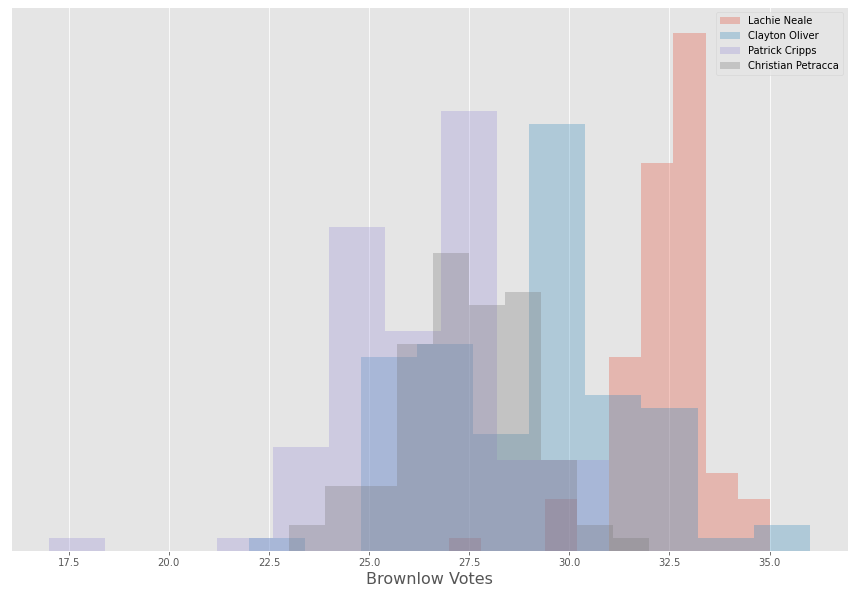

In [175]:
plt.figure(figsize=(15,10))
plt.hist(total_vote_count_sorted.loc['Lachie Neale'], alpha=0.3)
plt.hist(total_vote_count_sorted.loc['Clayton Oliver'], alpha=0.3)
plt.hist(total_vote_count_sorted.loc['Patrick Cripps'], alpha=0.3)
plt.hist(total_vote_count_sorted.loc['Christian Petracca'], alpha=0.3)
plt.legend(['Lachie Neale','Clayton Oliver','Patrick Cripps','Christian Petracca'])
plt.xlabel('Brownlow Votes', fontsize=16)
plt.yticks([])
plt.savefig('Brownlow_2022', dpi=400);

# By team

In [141]:
total_vote_count_by_team = (meta_data_2022[['ID','Full_Name','Playing_for']].drop_duplicates().
                            merge(total_vote_count.reset_index(), how='inner'))

In [144]:
total_vote_count_by_team['prediction_mean'] = total_vote_count_by_team.filter(regex='prediction_\d+').mean(axis=1)

In [150]:
total_vote_count_by_team['idxmax'] = total_vote_count_by_team.groupby(['Playing_for'])['prediction_mean'].transform('idxmax')

In [165]:
total_vote_count_by_team['best_player'] = total_vote_count_by_team['Full_Name'][total_vote_count_by_team['idxmax'].values].values

In [169]:
total_vote_count_by_team[['Playing_for','best_player']].drop_duplicates()

,Playing_for,best_player
0,Melbourne,Clayton Oliver
23,Western Bulldogs,Josh Dunkley
46,Carlton,Patrick Cripps
69,Richmond,Dion Prestia
92,St Kilda,Brad Crouch
115,Collingwood,Jack Crisp
138,Geelong,Jeremy Cameron
161,Essendon,Zach Merrett
184,Greater Western Sydney,Stephen Coniglio
207,Sydney,Luke Parker


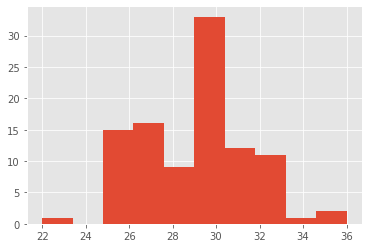

In [100]:
plt.hist(total_vote_count.sort_values(by='prediction_0', ascending=False).iloc[1]);

In [57]:
result_flat.shape

(910800, 7)

In [59]:
big_df = result_flat.merge(meta_data_2022)
big_df

,ID,Full_Name,game_id,variable,value,predicted_rank,brownlow_votes,Round,Playing_for,Jumper_No_,Home_team,Away_team,Venue,Date,Season,Local_start_time
0,12772,Toby Bedford,945,prediction_0,-0.004959,40.0,0,1,Melbourne,12 <U+2191>,Melbourne,Western Bulldogs,M.C.G.,2022-03-16,2022,1910
1,12772,Toby Bedford,945,prediction_1,-0.005015,38.0,0,1,Melbourne,12 <U+2191>,Melbourne,Western Bulldogs,M.C.G.,2022-03-16,2022,1910
2,12772,Toby Bedford,945,prediction_2,-0.003211,35.0,0,1,Melbourne,12 <U+2191>,Melbourne,Western Bulldogs,M.C.G.,2022-03-16,2022,1910
3,12772,Toby Bedford,945,prediction_3,-0.001831,39.0,0,1,Melbourne,12 <U+2191>,Melbourne,Western Bulldogs,M.C.G.,2022-03-16,2022,1910
4,12772,Toby Bedford,945,prediction_4,-0.005809,37.0,0,1,Melbourne,12 <U+2191>,Melbourne,Western Bulldogs,M.C.G.,2022-03-16,2022,1910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910795,12818,Sam Wicks,1142,prediction_95,0.013641,16.0,0,23,Sydney,15 <U+2191>,St Kilda,Sydney,Docklands,2022-08-21,2022,1640
910796,12818,Sam Wicks,1142,prediction_96,0.001880,27.0,0,23,Sydney,15 <U+2191>,St Kilda,Sydney,Docklands,2022-08-21,2022,1640
910797,12818,Sam Wicks,1142,prediction_97,-0.000447,29.0,0,23,Sydney,15 <U+2191>,St Kilda,Sydney,Docklands,2022-08-21,2022,1640
910798,12818,Sam Wicks,1142,prediction_98,0.005046,19.0,0,23,Sydney,15 <U+2191>,St Kilda,Sydney,Docklands,2022-08-21,2022,1640


In [76]:
def get_traces(name):
    df_traces = (big_df.
 query("Full_Name == @name").
 pivot_table('brownlow_votes','Round','variable', aggfunc='sum').
 cumsum())
    return df_traces

In [207]:
Lachie = get_traces('Lachie Neale')
Clayton = get_traces('Lachie Neale')
Petracca = get_traces('Christian Petracca')
Cripps = get_traces('Patrick Cripps')
Andrew = get_traces('Andrew Brayshaw')

In [214]:
Lachie = (big_df.
 query("Full_Name == 'Lachie Neale'").
 pivot_table('brownlow_votes','Round','variable', aggfunc='sum').
 cumsum())

Clayton = (big_df.
 query("Full_Name == 'Clayton Oliver'").
 pivot_table('brownlow_votes','Round','variable', aggfunc='sum').
 cumsum())

Petracca = (big_df.
 query("Full_Name == 'Christian Petracca'").
 pivot_table('brownlow_votes','Round','variable', aggfunc='sum').
 cumsum())

In [92]:
Lachie.median(axis=1).tail(1).squeeze()

32.5

In [203]:
Lachie

variable,prediction_0,prediction_1,prediction_10,prediction_11,prediction_12,prediction_13,prediction_14,prediction_15,prediction_16,prediction_17,prediction_18,prediction_19,prediction_2,prediction_20,prediction_21,prediction_22,prediction_23,prediction_24,prediction_25,prediction_26,prediction_27,prediction_28,prediction_29,prediction_3,prediction_30,prediction_31,prediction_32,prediction_33,prediction_34,prediction_35,prediction_36,prediction_37,prediction_38,prediction_39,prediction_4,prediction_40,prediction_41,prediction_42,prediction_43,prediction_44,prediction_45,prediction_46,prediction_47,prediction_48,prediction_49,prediction_5,prediction_50,prediction_51,prediction_52,prediction_53,prediction_54,prediction_55,prediction_56,prediction_57,prediction_58,prediction_59,prediction_6,prediction_60,prediction_61,prediction_62,prediction_63,prediction_64,prediction_65,prediction_66,prediction_67,prediction_68,prediction_69,prediction_7,prediction_70,prediction_71,prediction_72,prediction_73,prediction_74,prediction_75,prediction_76,prediction_77,prediction_78,prediction_79,prediction_8,prediction_80,prediction_81,prediction_82,prediction_83,prediction_84,prediction_85,prediction_86,prediction_87,prediction_88,prediction_89,prediction_9,prediction_90,prediction_91,prediction_92,prediction_93,prediction_94,prediction_95,prediction_96,prediction_97,prediction_98,prediction_99
Round,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,2,2,2,2,2,2,2,2,2,2,1,2,0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
2,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,6,5,5,5,5,5,5,5,5,5,5,4,5,3,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
3,5,5,5,6,7,7,6,7,5,5,5,6,5,5,7,6,5,5,5,5,7,5,5,5,5,5,4,5,3,5,5,5,6,6,5,6,6,5,5,5,5,6,5,5,5,5,5,5,5,6,5,5,5,5,5,5,7,5,5,5,5,5,5,6,6,5,5,6,5,5,5,5,5,5,5,5,5,5,5,4,5,5,4,6,5,5,5,5,5,5,7,5,7,5,6,5,5,6,6,5
4,7,7,7,8,9,9,7,8,6,7,7,7,7,6,8,7,7,6,6,7,9,7,6,6,7,7,6,6,4,7,7,7,8,7,7,8,7,7,7,7,6,8,7,7,6,6,5,7,7,7,7,7,6,7,7,7,9,7,7,7,6,7,6,8,8,7,7,7,6,6,7,7,6,6,7,6,7,6,6,6,6,7,6,7,6,6,7,6,7,7,7,7,9,7,8,7,7,8,7,7
5,10,10,10,11,12,11,10,10,8,10,9,10,10,9,11,10,9,9,8,10,12,9,9,8,10,9,8,8,6,10,9,10,11,10,9,10,10,10,9,9,8,11,9,10,8,8,8,10,10,10,9,10,9,10,10,9,11,10,10,9,9,10,9,11,10,10,10,10,9,8,10,10,9,9,10,9,10,9,8,8,9,10,9,10,8,9,10,9,10,9,10,10,12,10,11,10,10,11,9,9
6,10,10,10,11,12,11,10,10,8,10,9,10,10,9,11,10,9,9,8,10,12,9,9,8,10,9,8,8,6,10,9,10,11,10,9,10,10,10,9,9,8,11,9,10,8,8,8,10,10,10,9,10,9,10,10,9,11,10,10,9,9,10,9,11,10,10,10,10,9,8,10,10,9,9,10,9,10,9,8,8,9,10,9,10,8,9,10,9,10,9,10,10,12,10,11,10,10,11,9,9
7,13,13,13,14,15,14,13,13,11,13,12,13,13,12,14,13,12,12,11,13,15,12,12,11,13,12,11,11,9,13,12,13,14,13,12,13,13,13,12,12,11,14,12,13,11,11,11,13,13,13,12,13,12,13,13,12,14,13,13,12,12,13,12,14,13,13,13,13,12,11,13,13,12,12,13,12,13,12,11,11,12,13,12,13,11,12,13,12,13,12,13,13,15,13,14,13,13,14,12,12
8,15,15,15,16,17,16,15,15,13,14,14,15,15,14,16,15,14,13,13,15,17,14,14,13,15,14,13,13,11,15,14,15,16,15,14,15,15,15,14,14,13,16,14,15,13,13,13,15,15,15,14,15,14,15,15,14,16,15,15,14,14,14,14,16,15,15,15,15,14,13,15,15,14,14,15,14,15,14,13,13,14,15,14,15,13,14,15,14,15,14,15,15,17,15,16,15,15,16,14,14
9,18,18,18,19,20,19,18,18,16,17,17,18,18,17,19,18,17,16,16,18,20,17,17,16,18,17,16,16,14,18,17,18,19,18,17,18,18,18,17,17,16,19,17,18,16,16,16,18,18,18,17,18,17,18,18,17,19,18,18,17,17,17,17,19,18,18,18,18,17,16,18,18,17,17,18,17,18,17,16,16,17,18,17,18,16,17,18,17,18,17,18,18,20,18,19,18,18,19,17,17


In [205]:
Lachie.loc[15,:].mean()

23.36

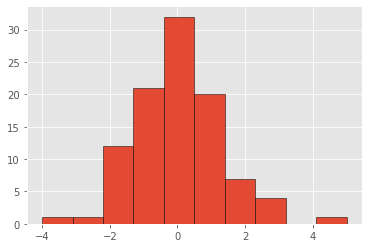

In [223]:
plt.hist(Lachie.loc[23,:].diff(), edgecolor='k');

In [219]:
Cripps.mean(axis=1).diff()

Round
1      NaN
2     2.29
3     2.90
4     0.00
6     1.77
7     2.99
8     2.89
9     0.05
10    0.00
11    0.19
13    2.97
14    0.00
15    0.06
16    0.77
17    0.13
18    0.00
19    2.58
20    0.69
21    0.00
22    0.26
23    2.83
dtype: float64

In [216]:
Andrew.mean(axis=1).diff()

Round
1      NaN
2     3.00
3     0.02
4     0.24
5     2.07
6     1.79
7     0.04
8     2.01
9     0.00
10    0.05
11    0.32
12    3.00
13    2.08
15    0.00
16    1.08
17    3.00
18    0.00
19    0.33
20    0.00
21    0.00
22    0.00
23    0.06
dtype: float64

In [220]:
Clayton.mean(axis=1).diff()

Round
1      NaN
2     0.24
3     3.00
4     0.00
5     1.60
6     3.00
7     1.54
8     1.53
9     0.43
10    2.90
11    0.69
12    0.00
13    2.26
15    1.57
16    1.86
17    0.48
19    0.05
20    0.00
21    2.63
22    0.15
23    3.00
dtype: float64

In [ ]:
Petracca = (big_df.
 query("Full_Name == 'Christian Petracca'").
 pivot_table('brownlow_votes','Round','variable', aggfunc='sum').
 cumsum())

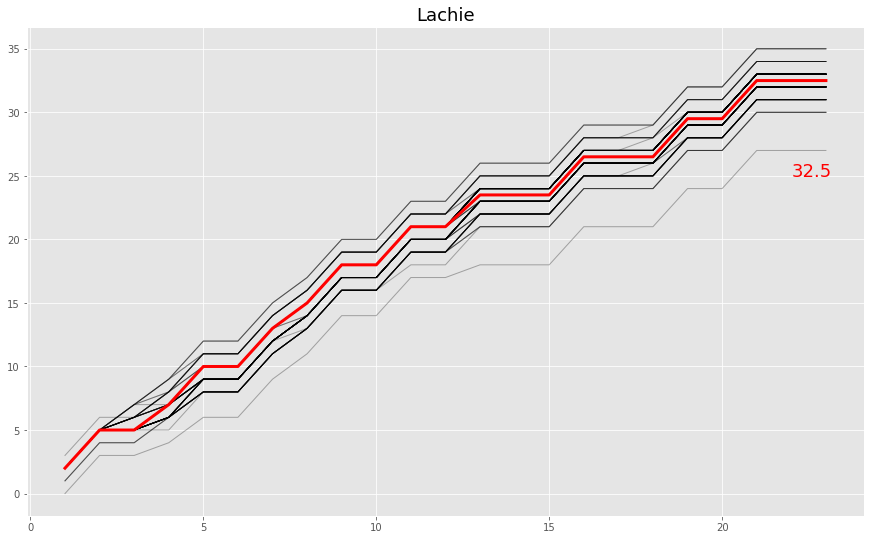

In [98]:
fig, ax = plt.subplots(figsize=(15,9))
plt.plot(Lachie, alpha=0.3, c='k', lw=1)
plt.plot(Lachie.median(axis=1), c='r', lw=3)
plt.title('Lachie', fontsize=18)
vote_likely = Lachie.median(axis=1).tail(1).squeeze()
plt.text(22, 25, s=vote_likely, fontsize=18, color='red');

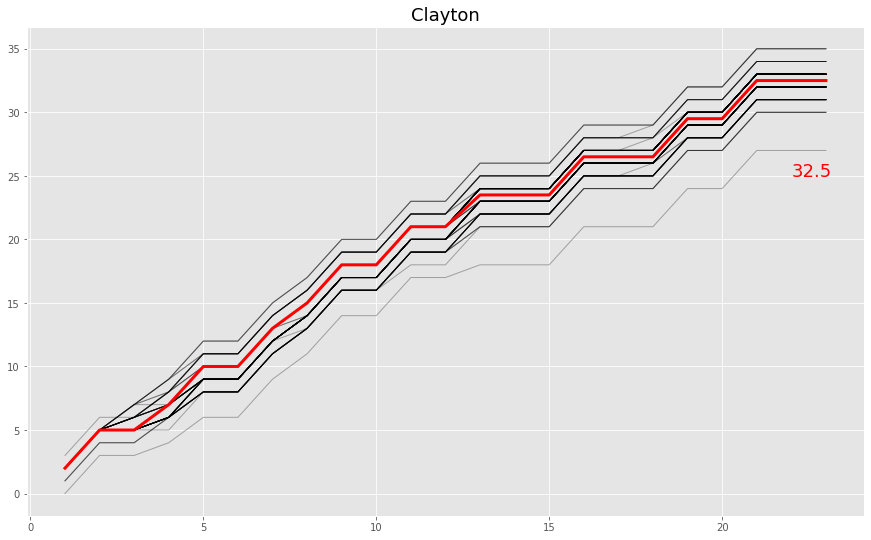

In [99]:
fig, ax = plt.subplots(figsize=(15,9))
plt.plot(Clayton, alpha=0.3, c='k', lw=1)
plt.plot(Clayton.median(axis=1), c='r', lw=3)
plt.title('Clayton', fontsize=18)
vote_likely = Clayton.median(axis=1).tail(1).squeeze()
plt.text(22, 25, s=vote_likely, fontsize=18, color='red');